# <font color="royalblue"><b> DETEKCIJA TEMA U *Youtube* KOMENTARIMA FANOVA EMISIE “GOING SEVENTEEN“ PRIMENOM BERTopic MODELA </b> </font>

## <font color="dodgerblue"><b> Imports </b> </font>

In [17]:
import spacy
import thinc

In [7]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.graph_objects as go

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN

from gensim import corpora
from gensim.models import CoherenceModel, Word2Vec

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

sns.set_theme(palette="pastel")

## <font color="dodgerblue"><b> Učitavanje i osnovna statistika </b> </font>

Podaci su prikupljeni sa YouTube kanala Going Seventeen putem YouTube Data API v3.
Skup podataka sadrži komentare iz dve kategorije:
- **recent** – komentari sa najnovijih videa i
- **popular** – komentari sa najgledanijih videa.

In [5]:
df = pd.read_csv('going_seventeen_comments.csv', encoding='utf-8-sig')
print(f'Ukupno redova: {len(df)}')
print(f'Kolone: {list(df.columns)}')
df.head()

Ukupno redova: 74552
Kolone: ['video_id', 'text', 'likes', 'date', 'video_title', 'type']


,video_id,text,likes,date,video_title,type
0,TJWUc875kpU,I think the production team could also create ...,0,2026-04-04T10:58:36Z,[GOING SEVENTEEN SPECIAL] 2026 고잉 긴급 회의 (Agend...,recent
1,TJWUc875kpU,"Honestly, i agree with Dino. I think they keep...",0,2026-04-04T06:20:04Z,[GOING SEVENTEEN SPECIAL] 2026 고잉 긴급 회의 (Agend...,recent
2,TJWUc875kpU,I’m glad Minghao brought up that he and Jun fe...,0,2026-04-04T00:35:36Z,[GOING SEVENTEEN SPECIAL] 2026 고잉 긴급 회의 (Agend...,recent
3,TJWUc875kpU,"I understand the discussion, but I think I wou...",0,2026-04-03T15:37:59Z,[GOING SEVENTEEN SPECIAL] 2026 고잉 긴급 회의 (Agend...,recent
4,TJWUc875kpU,Unpopular opinion: please bring the resolution...,2,2026-04-02T22:35:00Z,[GOING SEVENTEEN SPECIAL] 2026 고잉 긴급 회의 (Agend...,recent


In [6]:
print('=== OSNOVNA STATISTIKA ===')
print(f'Ukupno komentara:  {len(df):,}')
print(f'\nPo tipu videa:')
print(df['type'].value_counts().to_string())
print(f'\nPo videu:')
print(df['video_title'].value_counts().to_string())
print(f'\nLikes – prosek: {df["likes"].mean():.2f},  max: {df["likes"].max()}')

=== OSNOVNA STATISTIKA ===
Ukupno komentara:  74,552

Po tipu videa:
type
popular    64652
recent      9900

Po videu:
video_title
[GOING SEVENTEEN 2020] EP.27 술래잡기 #1 (The Tag #1)                                      11325
[GOING SEVENTEEN 2020] EP.44 TTT #1 (Hyperrealism Ver.)                                 8523
[GOING SEVENTEEN 2020] EP.25 디에잇과 12인의 그림자 #1 (THE 8 and the 12 Shadows #1)             7405
[GOING SEVENTEEN 2020] EP.45 TTT #2 (Hyperrealism Ver.)                                 6679
[GOING SEVENTEEN 2020] EP.23 드립 : 세븐틴 갓 탤런트 #1 (Ad-lib : Seventeen's got Talent #1)     6536
[GOING SEVENTEEN 2020] EP.40 돈't Lie Ⅱ #1 (Don't Lie Ⅱ #1)                              6126
[GOING SEVENTEEN] EP.32 순응특집 단짝 #2 (Best Friends #2)                                    5167
[GOING SEVENTEEN] EP.31 순응특집 단짝 #1 (Best Friends #1)                                    4676
[GOING SEVENTEEN] EP.18 TTT에 빠지다 #1 (Dive into TTT #1)                                  4516
[GOING SEVENTEEN] EP.24 부족오락관 #2

## <font color="dodgerblue"><b> Analiza teksta </b> </font>

Pre primene ikakvih NLP transformacija, analiziramo sirove komentare:
- **Dužinu komentara** 
- **Vokabular** 
- **Leksicku raznovrsnost (TTR)**

### <font color="steelblue"><b> Dužina komentara </b> </font>

=== STATISTIKA DUŽINE KOMENTARA ===
       char_count  word_count  sent_count
count    74552.00    74552.00    74552.00
mean       107.39       16.57        2.41
std        146.59       21.34        3.09
min          2.00        1.00        1.00
25%         46.00        7.00        1.00
50%         79.00       12.00        2.00
75%        123.00       18.00        3.00
max       8827.00      995.00      201.00


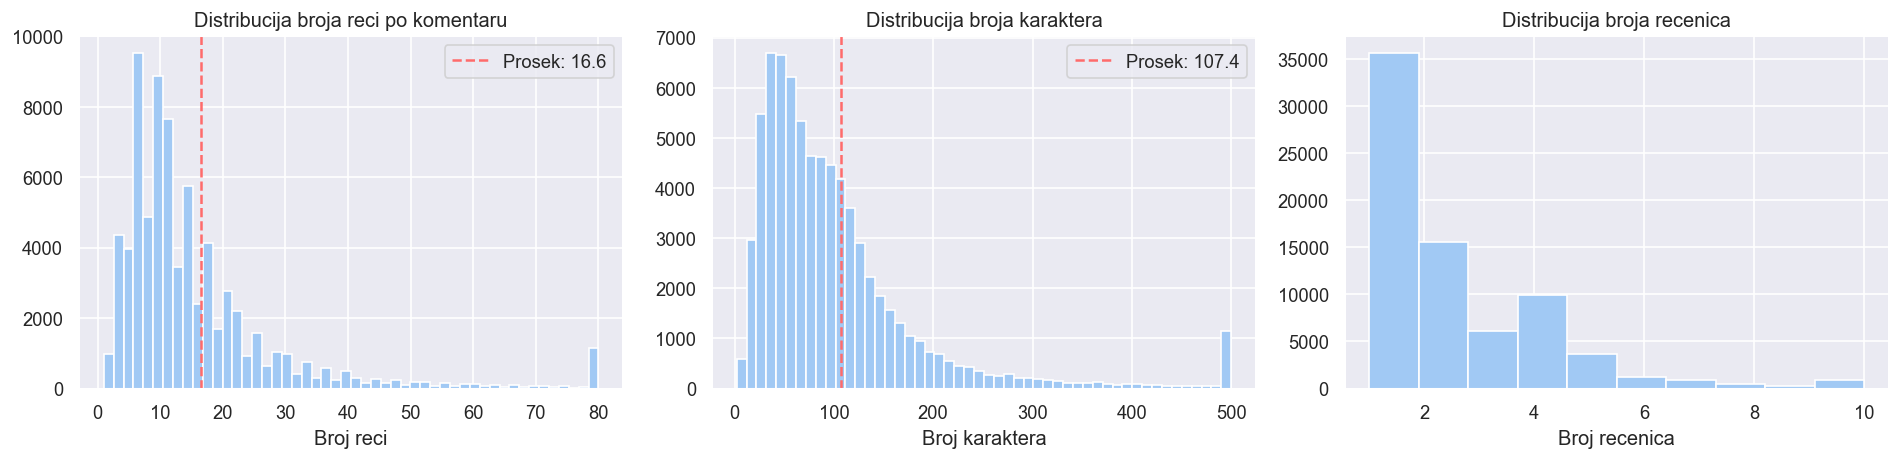

In [9]:
df['char_count'] = df['text'].apply(lambda x: len(str(x)))
df['word_count']  = df['text'].apply(lambda x: len(str(x).split()))
df['sent_count']  = df['text'].apply(
    lambda x: max(1, len(re.split(r'[.!?]+', str(x).strip()))))

desc = df[['char_count', 'word_count', 'sent_count']].describe().round(2)
print('=== STATISTIKA DUŽINE KOMENTARA ===')
print(desc)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['word_count'].clip(upper=80), bins=50, edgecolor='white')
axes[0].axvline(df['word_count'].mean(), color='#FF6B6B', linestyle='--',
                label=f'Prosek: {df["word_count"].mean():.1f}')
axes[0].set_title('Distribucija broja reci po komentaru')
axes[0].set_xlabel('Broj reci')
axes[0].legend()

axes[1].hist(df['char_count'].clip(upper=500), bins=50, edgecolor='white')
axes[1].axvline(df['char_count'].mean(), color='#FF6B6B', linestyle='--',
                label=f'Prosek: {df["char_count"].mean():.1f}')
axes[1].set_title('Distribucija broja karaktera')
axes[1].set_xlabel('Broj karaktera')
axes[1].legend()

axes[2].hist(df['sent_count'].clip(upper=10), bins=10, edgecolor='white')
axes[2].set_title('Distribucija broja recenica')
axes[2].set_xlabel('Broj recenica')

plt.tight_layout()
plt.show()

Statistika pokazuje da su komentari uglavnom **kratki i spontani** - prosečno oko 16 reči i 107 karaktera, sa 2-3 rečenice. Većina komentara sadrži 5-20 reči, dok su veoma dugi komentari retki. Ova varijabilnost ukazuje na to da fanovi kombinuje brze emotivne reakcije (kratki komentari, slang, emoji-ji) sa manjim brojem detaljnih analiza epizoda. Takva struktura potvrđuje da je detekcija tema izazovna i da su modeli zasnovani na semantičkim reprezentacijama (BERTopic) pogodniji od klasičnih pristupa.

### <font color="steelblue"><b> Vokabular i leksicka raznovrsnost (TTR) </b> </font>

In [14]:
STOP_WORDS = set(stopwords.words('english')) | {
    'im', 'ive', 'dont', 'cant', 'wont', 'didnt', 'isnt', 'wasnt',
    'youre', 'theyre', 'theyve', 'wouldnt', 'shouldnt', 'couldnt',
    'na', 'gonna', 'gotta', 'kinda', 'wanna', 'lol', 'omg', 'lmao',
    'yeah', 'yea', 'nah', 'ok', 'okay', 'ngl',
    'href', 'bra', 'amp', 'quot', 'br', 'lt', 'gt',
}

df['ttr'] = df['text'].apply(
    lambda x: len(set(re.findall(r'[a-z]+', str(x).lower()))) /
              max(len(re.findall(r'[a-z]+', str(x).lower())), 1)
)

HTML_ARTIFACTS = {'href', 'bra', 'amp', 'quot', 'br', 'lt', 'gt', 'http', 'https', 'www', 'com'}
all_words_raw = []
for tekst in df['text']:
    words = re.findall(r'[a-z]+', str(tekst).lower())
    words = [w for w in words if w not in HTML_ARTIFACTS]
    all_words_raw.extend(words)

total_tokens  = len(all_words_raw)
unique_tokens = len(set(all_words_raw))
ttr_global    = unique_tokens / total_tokens

print('=== VOKABULAR (sirovi tekst, bez HTML artefakata) ===')
print(f'Ukupno tokena:      {total_tokens:,}')
print(f'Jedinstvenih reči:  {unique_tokens:,}')
print(f'Globalni TTR:       {ttr_global:.4f}')
print(f'\nProsečni TTR po komentaru: {df["ttr"].mean():.4f}') # da li mi stvarno treba?

=== VOKABULAR (sirovi tekst, bez HTML artefakata) ===
Ukupno tokena:      1,355,978
Jedinstvenih reči:  26,681
Globalni TTR:       0.0197

Prosečni TTR po komentaru: 0.9251


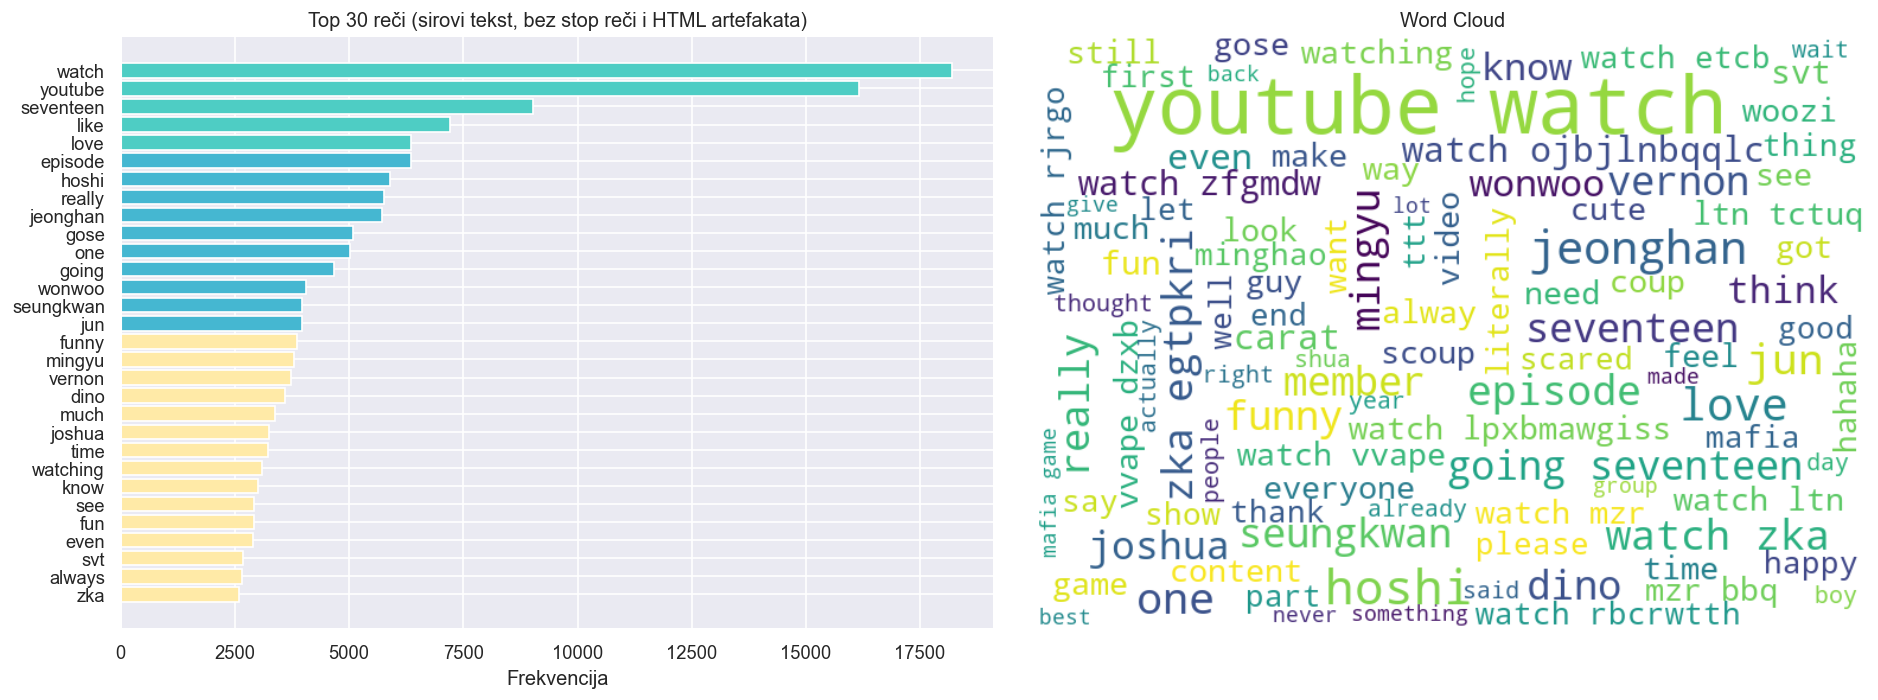

In [15]:
filtered_words = [w for w in all_words_raw if w not in STOP_WORDS and len(w) > 2]
word_freq = Counter(filtered_words)
top30 = word_freq.most_common(30)
words_top, counts_top = zip(*top30)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_bar = ['#4ECDC4' if i < 5 else '#45B7D1' if i < 15 else '#FFEAA7'
              for i in range(len(words_top))]
axes[0].barh(list(reversed(words_top)), list(reversed(counts_top)),
             color=list(reversed(colors_bar)), edgecolor='white')
axes[0].set_title('Top 30 reči (sirovi tekst, bez stop reči i HTML artefakata)')
axes[0].set_xlabel('Frekvencija')

wc = WordCloud(width=700, height=500, background_color='white',
               colormap='viridis', max_words=100).generate(' '.join(filtered_words))
axes[1].imshow(wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud')

plt.tight_layout()
plt.show()

Najčešće reči u komentarima su *watch*, *youtube*, *seventeen*, *episode*, *love* i *like*, što ukazuje na spontano izražavanje emocija i fokus na samu emisiju. Pojava imena članova grupe (Hoshi, Jeonghan, Jun, Joshua, Seungkwan) potvrđuje da fanovi aktivno komentarišu pojedince. Word cloud vizualizacija dodatno naglašava centralne teme: naziv emisije, članove grupe i emotivne reakcije publike (*funny*, *love*). Ovi nalazi pokazuju da fan zajednica kombinuje tehničke reference na platformu (YouTube, gledanje epizoda) sa sadržajem emisije i izražavanjem podrške članovima.

### <font color="steelblue"><b> Bigram analiza </b> </font>

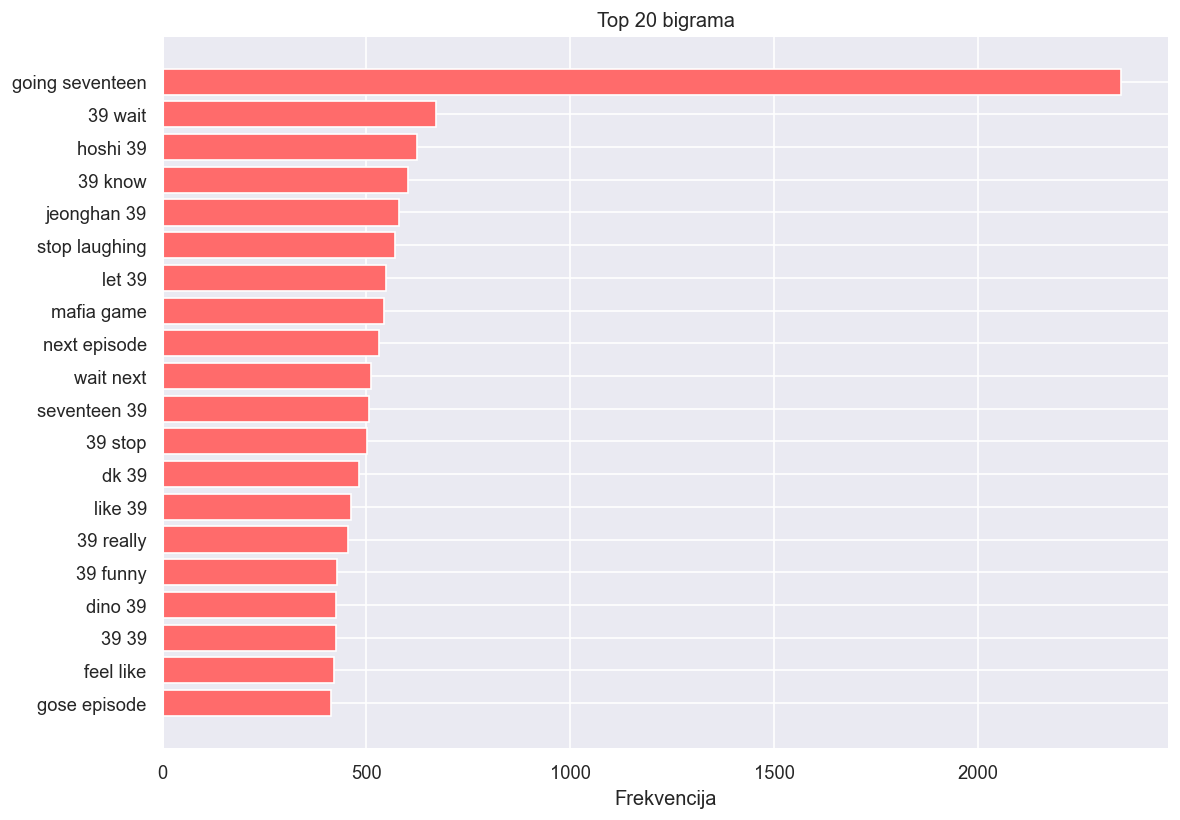

In [16]:
corpus_clean = []
for t in df['text']:
    txt = re.sub(r'<[^>]+>', ' ', str(t))
    txt = re.sub(r'&\w+;', ' ', txt)
    txt = txt.lower()
    corpus_clean.append(txt)

bigram_vec = CountVectorizer(ngram_range=(2, 2), stop_words=list(STOP_WORDS),
                 max_features=25, min_df=5)
bigram_vec.fit(corpus_clean)
b_counts = np.asarray(bigram_vec.transform(corpus_clean).sum(axis=0)).flatten()
b_names  = bigram_vec.get_feature_names_out()
top_bi   = sorted(zip(b_names, b_counts), key=lambda x: x[1], reverse=True)[:20]

bi_words, bi_vals = zip(*top_bi)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(list(reversed(bi_words)), list(reversed(bi_vals)),
        color='#FF6B6B', edgecolor='white')
ax.set_title('Top 20 bigrama')
ax.set_xlabel('Frekvencija')
plt.tight_layout()
plt.show()

Rezultati pokazuju da je najčešći bigram **„going seventeen“**, što potvrđuje da fanovi direktno pominju naziv emisije i da je ona centralna tema diskusije. Pored toga, pojavljuju se imena članova grupe (Hoshi, Jeonghan, DK, Dino), što ukazuje na fokus fanova na pojedinačne članove. Fraze poput **„stop laughing“**, **„mafia game“**, **„next episode“** i **„gose episode“** odražavaju tipične segmente emisije i reakcije publike na humor i igre. Artefakt „39“ potiče od HTML enkodiranja (`&#39;` = apostrof) i pokazuje da je predobrada teksta neophodna kako bi se uklonili tehnički šumovi. Ukupno, bigram analiza otkriva kombinaciju tematskih referenci na emisiju i emotivnih reakcija fanova.

## <font color="dodgerblue"><b> Predobrada teksta </b> </font>

### <font color="steelblue"><b> Normalizacija </b> </font>

### <font color="steelblue"><b> Tokenizacija </b> </font>

### <font color="steelblue"><b> Uklanjanje stop reči </b> </font>

### <font color="steelblue"><b> Lematizacija </b> </font>

## <font color="dodgerblue"><b> Popularnost clanova grupe – rangiranje po pominjanju </b> </font>

## <font color="dodgerblue"><b> Reprezentacija teksta </b> </font>

### <font color="steelblue"><b> Bag of Words </b> </font>

### <font color="steelblue"><b> TF-IDF </b> </font>

### <font color="steelblue"><b> Word2Vec </b> </font>

## <font color="dodgerblue"><b> BERTopic – Varijanta A: Sentence Transformers + c-TF-IDF </b> </font>

## <font color="dodgerblue"><b> BERTopic – Varijanta B: Word2Vec doc embeddings </b> </font>

## <font color="dodgerblue"><b> LDA - Baseline </b> </font>

## <font color="dodgerblue"><b> NMF - Baseline </b> </font>

## <font color="dodgerblue"><b> Analiza tema po popularnim vs. nedavnim epizodama </b> </font>

## <font color="dodgerblue"><b> Analiza Wish komentara – Sta fanovi zele da gledaju? </b> </font>

## <font color="dodgerblue"><b> Vizuelizacije </b> </font>

### <font color="steelblue"><b> BERTopic – interaktivne vizualizacije (c-TF-IDF) </b> </font>

### <font color="steelblue"><b> Word Clouds – BERTopic c-TF-IDF </b> </font>

### <font color="steelblue"><b> Heatmapa tema po videu </b> </font>

## <font color="dodgerblue"><b> Evaluacija i poredenje modela </b> </font>

## <font color="dodgerblue"><b> Rezime </b> </font>